# 02 — Modelling and evaluation (Phases 2–3)

This notebook **reads saved results only**. It fits nothing and does not re-score the test segment. All numbers
come from `scripts/train_evaluate.py` (`develop` → `freeze` → one-time `test` → `random-split-diagnostic`) and
`scripts/make_figures.py`.

**Decision point:** a lead is scored immediately before the recorded outbound call is dialled.

**Headline evaluation:** chronological. Models are fitted on May 2008 – March 2009, model choice and Platt
calibration use April – May 2009, and the untouched final 20% (May 2009 – November 2010) was scored once.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
REPORTS = Path.cwd().parent / "reports"
spec = json.loads((REPORTS / "frozen_spec.json").read_text())
val = json.loads((REPORTS / "validation_metrics.json").read_text())
test = json.loads((REPORTS / "metrics.json").read_text())
diag = json.loads((REPORTS / "random_split_diagnostic.json").read_text())


def topk_frame(result):
    rows = []
    for name, m in result.items():
        for r in m["top_k"]:
            rows.append({"model": name, "top": f"{int(r['top_fraction'] * 100)}%", "precision": r["precision"],
                         "share_captured": r["capture_rate"], "lift": r["lift"],
                         "contacts_per_conversion": r["contacts_per_conversion"]})
    return pd.DataFrame(rows).round(3)

## 1. Segments and drift

In [2]:
pd.read_csv(REPORTS / 'contiguous_segment_summary.csv').set_index('segment').T

segment,development,validation,test
first_row,0,27972,32949
last_row,27971,32948,41187
n_rows,27972,4977,8239
share_of_all_rows,0.67913,0.120836,0.200034
first_period,2008-05,2009-04,2009-05
last_period,2009-03,2009-05,2010-11
conversion_rate,0.052374,0.127587,0.30829
n_pdays_recorded,39,135,1341
share_pdays_recorded,0.001394,0.027125,0.162762
n_previous_gt_0,756,1519,3350


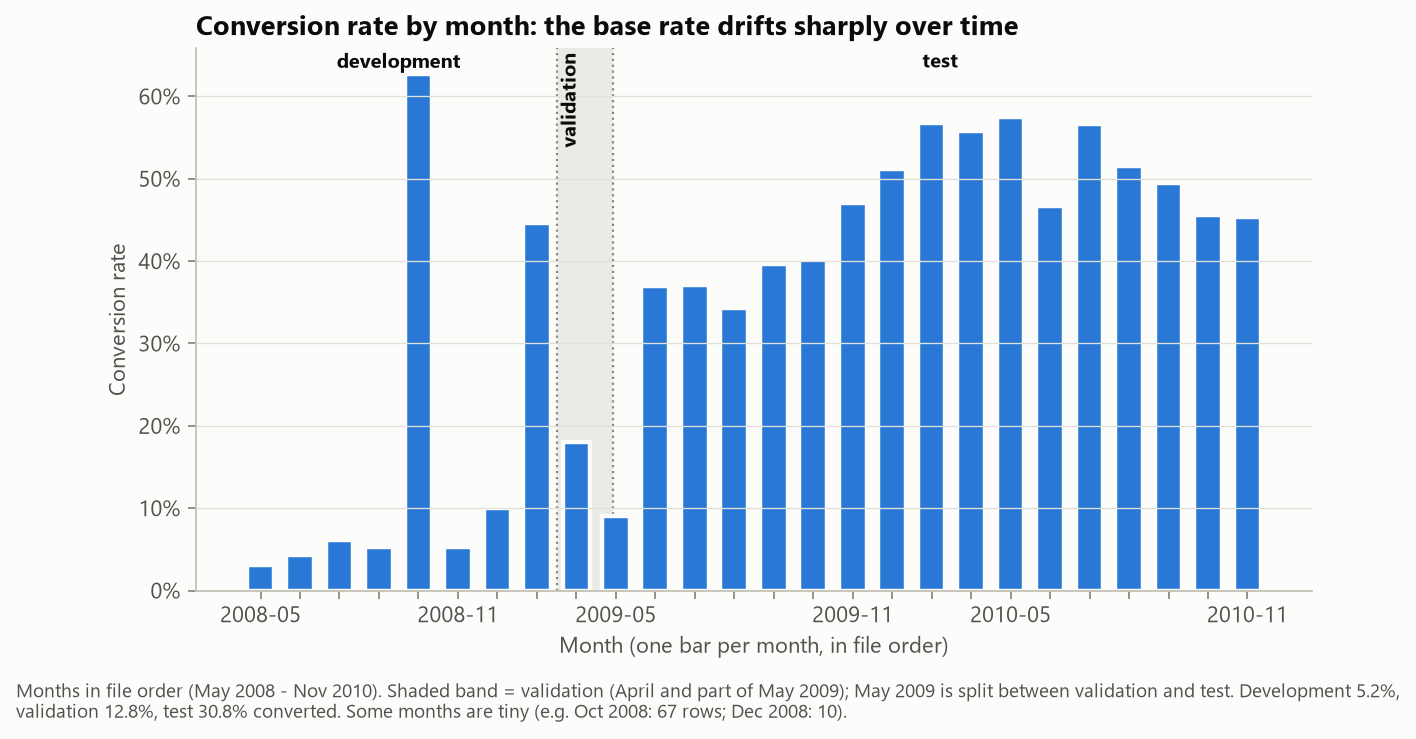

In [3]:
display(Image(REPORTS / 'figures' / 'conversion_rate_by_month.png'))

The base rate rises from 5.2% (development) to 12.8% (validation) to 30.8% (test), and prior-campaign
history becomes far more common. **May 2009 is split between validation and test**: the segments are row-wise
chronological and non-overlapping, but not fully month-disjoint.

## 2. Frozen specification

In [4]:
print("Primary features:", spec["feature_sets"]["primary"])
print("Primary model:", spec["primary_model"], spec["params"]["logreg"])
print("Comparison model: XGBoost", spec["params"]["xgboost"])
print("Calibration:", {k: spec["calibration"][k] for k in ("method", "slope", "intercept", "used")})
print("Priority bands:", spec["priority_bands"])

Primary features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'prior_contacts_current_campaign', 'previous', 'poutcome']
Primary model: primary__logreg {'C': 1.0}
Comparison model: XGBoost {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 20, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.8}
Calibration: {'method': "Platt: logistic regression on the model's log-odds", 'slope': 1.2584550448535217, 'intercept': 1.456414277004645, 'used': True}
Priority bands: NOT DEFINED. High/Medium/Low bands belong to Phase 4 and are not part of this spec.


### Tuning was not informative
Inside the development period, every candidate scored at noise level relative to the naive baseline, so the
predeclared defaults were used rather than the noisy best candidates.

In [5]:
pd.DataFrame(spec['tuning']['results']).T

,informative,chosen_params,best_params,best_mean_pr_auc,default_mean_pr_auc,mean_gain_over_default,gain_standard_error,pr_auc_spread_across_candidates
logreg,False,{'C': 1.0},{'C': 0.003},0.063137,0.061021,0.002117,0.00431,0.00454
xgboost,False,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 20, 'n_estimators': 100, 'reg_la...","{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'reg_la...",0.062587,0.059845,0.002741,0.003475,0.005158


In [6]:
pd.read_csv(REPORTS / 'cv_summary.csv').head(10)[['family', 'params', 'pr_auc_mean', 'pr_auc_std', 'roc_auc_mean']]

,family,params,pr_auc_mean,pr_auc_std,roc_auc_mean
0,logreg,{'C': 0.003},0.063137,0.017575,0.506234
1,xgboost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'reg_la...",0.062587,0.016555,0.501000
2,xgboost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'reg_la...",0.062274,0.015192,0.501802
3,logreg,{'C': 0.01},0.061199,0.015409,0.501617
4,xgboost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 400, 'reg_la...",0.061077,0.013752,0.502538
5,xgboost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 20, 'n_estimators': 200, 'reg_l...",0.061031,0.013134,0.504531
6,logreg,{'C': 1.0},0.061021,0.013543,0.512014
7,logreg,{'C': 0.1},0.060585,0.015219,0.501328
8,xgboost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 20, 'n_estimators': 400, 'reg_l...",0.060486,0.012787,0.504592
9,logreg,{'C': 0.03},0.060218,0.014650,0.500756


## 3. Out-of-time validation (April – May 2009) — basis for model choice

In [7]:
pd.DataFrame({name: {k: m[k] for k in ("pr_auc", "roc_auc", "brier", "mean_predicted")} | {"pr_auc_by_month": m["pr_auc_by_period"]}
              for name, m in val["models"]["primary"].items()}).T

,pr_auc,roc_auc,brier,mean_predicted,pr_auc_by_month
naive,0.127587,0.5,0.116965,0.052374,"{'2009-04': 0.17982099267697316, '2009-05': 0.07661770543866614}"
logreg,0.199868,0.626969,0.113556,0.063771,"{'2009-04': 0.26958964681270775, '2009-05': 0.1205948698447431}"
xgboost,0.213078,0.615606,0.113687,0.062284,"{'2009-04': 0.2850924842310296, '2009-05': 0.11141817257857652}"


In [8]:
topk_frame(val['models']['primary'])

,model,top,precision,share_captured,lift,contacts_per_conversion
0,naive,10%,0.128,0.100,1.000,7.838
1,naive,20%,0.128,0.200,1.000,7.838
2,naive,30%,0.128,0.300,1.000,7.838
3,logreg,10%,0.269,0.211,2.109,3.716
4,logreg,20%,0.210,0.329,1.646,4.761
5,logreg,30%,0.192,0.452,1.507,5.202
6,xgboost,10%,0.279,0.219,2.188,3.583
7,xgboost,20%,0.212,0.332,1.662,4.716
8,xgboost,30%,0.189,0.444,1.480,5.294


In [9]:
spec['primary_checks']

{'eligible': {'logreg': True, 'xgboost': True},
 'xgboost_checks': {'pr_auc_gain_at_least_min': True,
  'top20_lift_at_least_logreg': True,
  'pr_auc_at_least_logreg_every_month': False},
 'top20_lift': {'logreg': 1.6463308669330907, 'xgboost': 1.6620852292960868}}

XGBoost passed the PR-AUC and top-20% lift checks but not temporal stability (lower PR-AUC in May 2009), so the
simpler logistic regression is primary under the predeclared rule.

Sensitivity sets (validation only, never used for any decision):

In [10]:
pd.DataFrame({f"{fs} / {fam}": {k: m[k] for k in ("pr_auc", "roc_auc", "brier", "mean_predicted")}
              for fs, models in val["models"].items() if fs != "primary" for fam, m in models.items()}).T.round(3)

,pr_auc,roc_auc,brier,mean_predicted
month_sensitivity / logreg,0.213,0.658,0.110,0.078
month_sensitivity / xgboost,0.222,0.657,0.114,0.056
pdays_sensitivity / logreg,0.197,0.614,0.115,0.066
pdays_sensitivity / xgboost,0.209,0.610,0.114,0.062
extended / logreg,0.193,0.622,0.132,0.277
extended / xgboost,0.166,0.583,0.178,0.382


Error analysis on validation (primary model, before calibration):

In [11]:
pd.read_csv(REPORTS / 'error_analysis_validation.csv').round(3)

,level,n,observed_rate,mean_predicted,share_of_conversions,column
0,cellular,4660,0.129,0.065,0.946,contact
1,telephone,317,0.107,0.041,0.054,contact
2,failure,1389,0.068,0.047,0.148,poutcome
3,nonexistent,3458,0.140,0.069,0.761,poutcome
4,success,130,0.446,0.112,0.091,poutcome
5,fri,1077,0.069,0.068,0.117,day_of_week
6,mon,1269,0.110,0.058,0.219,day_of_week
7,thu,1251,0.183,0.063,0.361,day_of_week
8,tue,613,0.139,0.062,0.134,day_of_week
9,wed,767,0.141,0.070,0.170,day_of_week


## 4. One-time chronological test (May 2009 – November 2010) — headline result

In [12]:
rows = {}
for name, m in test["models"].items():
    rows[name] = {k: m[k] for k in ("pr_auc", "roc_auc", "brier", "mean_predicted")}
    if name in test["bootstrap"]:
        rows[name] |= {"pr_auc_95ci": test["bootstrap"][name]["pr_auc"], "roc_auc_95ci": test["bootstrap"][name]["roc_auc"]}
pd.DataFrame(rows).T

,pr_auc,roc_auc,brier,mean_predicted,pr_auc_95ci,roc_auc_95ci
naive,0.30829,0.5,0.27874,0.052374,NaN,NaN
logreg_primary,0.458801,0.644691,0.262034,0.072549,"[0.43954875107800334, 0.47968400242545317]","[0.6316369877432663, 0.6582137355605538]"
xgboost_comparison,0.39094,0.5879,0.26678,0.070127,"[0.3744258886562903, 0.4102027823248212]","[0.5750535151399104, 0.6012512782235624]"


In [13]:
test['bootstrap']['differences']

{'logreg_primary - xgboost_comparison': {'pr_auc': [0.05082378423910387,
   0.08456175114615162],
  'roc_auc': [0.045038808693136416, 0.06823631352915986]}}

In [14]:
print(test['bootstrap']['settings']['caveat'])

Nonparametric row bootstrap (rows resampled with replacement, same resamples for every model). Intervals describe row-level sampling uncertainty under an independence approximation. They do not capture temporal dependence, distribution drift, or repeated clients (no client ID is available).


In [15]:
topk_frame(test['models'])

,model,top,precision,share_captured,lift,contacts_per_conversion
0,naive,10%,0.308,0.100,1.000,3.244
1,naive,20%,0.308,0.200,1.000,3.244
2,naive,30%,0.308,0.300,1.000,3.244
3,logreg_primary,10%,0.553,0.180,1.795,1.807
4,logreg_primary,20%,0.544,0.353,1.764,1.839
5,logreg_primary,30%,0.472,0.459,1.530,2.120
6,xgboost_comparison,10%,0.483,0.157,1.567,2.070
7,xgboost_comparison,20%,0.422,0.274,1.368,2.371
8,xgboost_comparison,30%,0.386,0.375,1.251,2.594


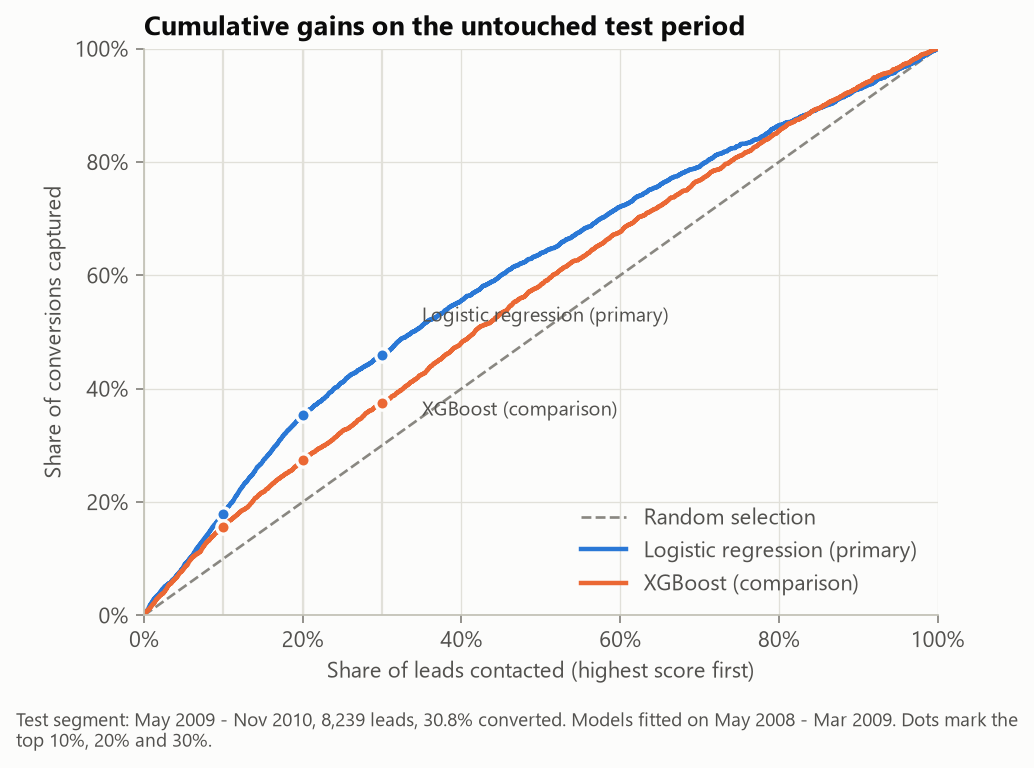

In [16]:
display(Image(REPORTS / 'figures' / 'test_gains_curve.png'))

### Calibration on test

In [17]:
pd.Series(test['primary_calibration'])

brier_before                        0.262034
brier_after                         0.227655
brier_at_segment_base_rate          0.213247
mean_predicted_before               0.072549
mean_predicted_after                0.147379
actual_rate                          0.30829
ranking_unchanged_by_calibration        True
dtype: object

In [18]:
pd.read_csv(REPORTS / 'calibration_test.csv').round(3)

,bin,n,mean_predicted,observed_rate,stage
0,0,824,0.032,0.221,before calibration
1,1,824,0.043,0.197,before calibration
2,2,824,0.049,0.226,before calibration
3,3,824,0.056,0.218,before calibration
4,4,824,0.062,0.252,before calibration
5,5,823,0.068,0.255,before calibration
6,6,824,0.073,0.299,before calibration
7,7,824,0.082,0.328,before calibration
8,8,824,0.101,0.534,before calibration
9,9,824,0.161,0.553,before calibration


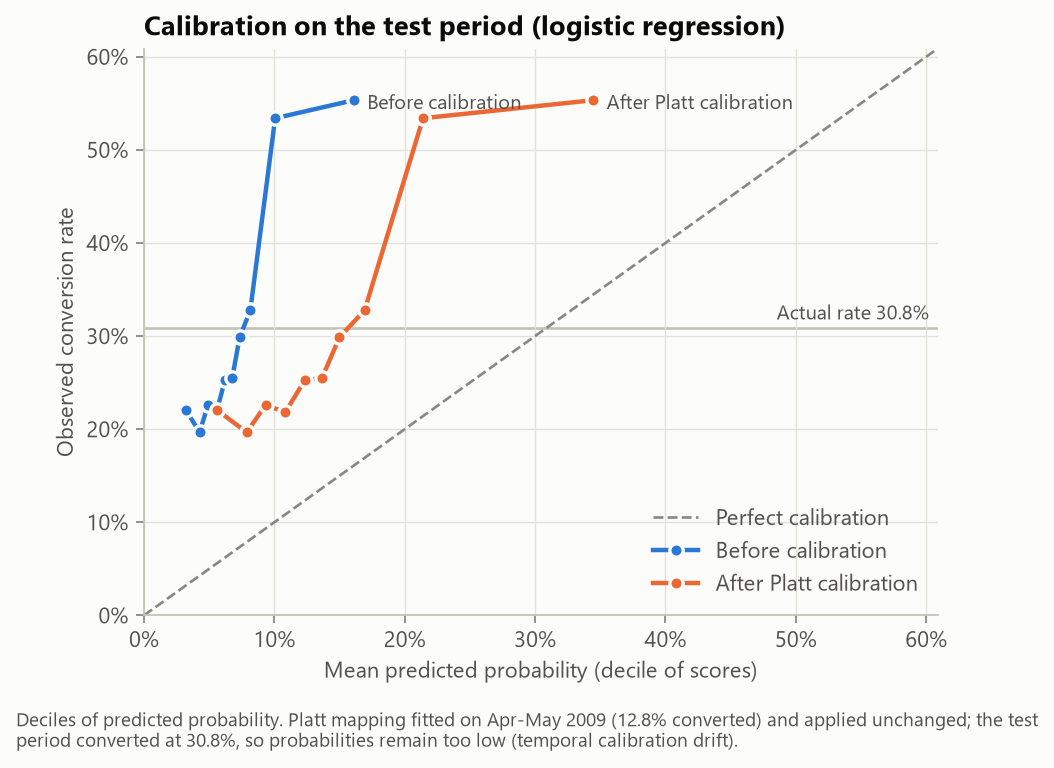

In [19]:
display(Image(REPORTS / 'figures' / 'test_calibration.png'))

The Platt mapping was fitted on a period converting at 12.8% and applied unchanged to a period converting at
30.8%. It roughly doubles the mean prediction (7.3% → 14.7%) but remains far below the actual rate, and its Brier
score is still worse than always predicting the test period's own rate (which is not knowable in advance). This is
**temporal calibration drift**; it was not corrected on the test set. Ranking is unaffected by calibration.

## 5. Random-split diagnostic — optimistic, not a headline

In [20]:
print(diag["note"])
pd.DataFrame({name: {k: m[k] for k in ("pr_auc", "roc_auc", "brier", "mean_predicted")} for name, m in diag["models"].items()}).T

OPTIMISTIC DIAGNOSTIC ONLY. Frozen recipe (features, hyperparameters, Platt calibration) on a stratified random 70/10/20 split of all rows, so training, calibration and evaluation rows share periods. Shows how optimistic random evaluation is; not a headline result and not used to revise or select the production model.


,pr_auc,roc_auc,brier,mean_predicted
naive,0.112649,0.500000,0.099959,0.112657
logreg_primary,0.370020,0.741589,0.085232,0.111705
xgboost_comparison,0.390691,0.745592,0.084007,0.111934


In [21]:
topk_frame(diag['models'])

,model,top,precision,share_captured,lift,contacts_per_conversion
0,naive,10%,0.113,0.100,1.000,8.877
1,naive,20%,0.113,0.200,1.000,8.877
2,naive,30%,0.113,0.300,1.000,8.877
3,logreg_primary,10%,0.394,0.350,3.501,2.535
4,logreg_primary,20%,0.270,0.480,2.397,3.703
5,logreg_primary,30%,0.226,0.601,2.005,4.428
6,xgboost_comparison,10%,0.426,0.378,3.781,2.348
7,xgboost_comparison,20%,0.279,0.496,2.478,3.583
8,xgboost_comparison,30%,0.230,0.613,2.044,4.343


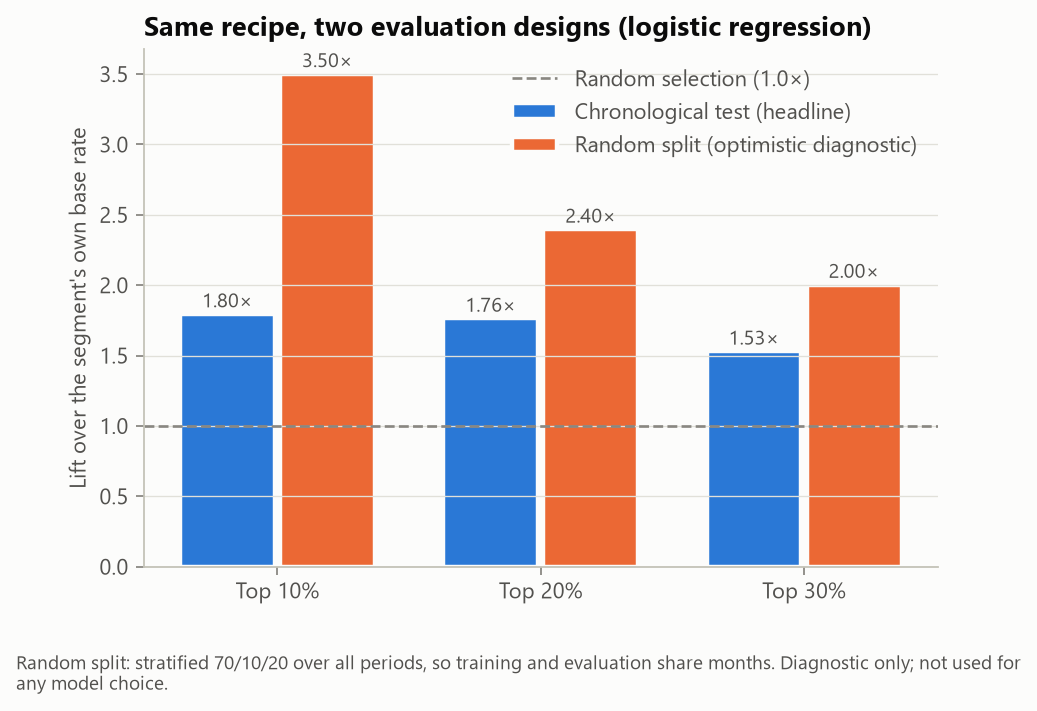

In [22]:
display(Image(REPORTS / 'figures' / 'lift_chronological_vs_random.png'))

Absolute PR-AUC is not comparable across the two designs because the base rates differ (11.3% vs 30.8%);
lift, ROC-AUC and calibration are. Under a random split the same recipe looks markedly better and well calibrated,
and XGBoost edges out logistic regression — the opposite of the chronological result. A random split would have
overstated performance and pointed to a different model.

## Limitations
- One bank, one country, 2008–2010 (financial crisis); results are a backtest, not a forecast.
- Strong drift in base rate and population; prior-campaign history is rare in the development period.
- May 2009 is split between validation and test.
- Bootstrap intervals assume independent rows; they ignore temporal dependence, drift and repeated clients.
- Priority bands are **not** defined yet (Phase 4).